In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pd.read_pickle('raw_elia_data_cleaned.pkl')

In [24]:
# Show first rows of data
df.head(100)

,Datetime,Resolution code,Quarter hour,Quality status,ACE,System imbalance,Alpha,Alpha',Marginal incremental price,Marginal decremental price,Imbalance Price
0,2024-05-21 22:00:00+00:00,PT1M,2024-05-21T22:00:00+00:00,NV,78.944,118.189,0.0,NaN,148.64,-94.442,-94.442
1,2024-05-21 22:01:00+00:00,PT1M,2024-05-21T22:00:00+00:00,NV,53.208,93.526,0.0,NaN,148.64,-155.739,-155.739
2,2024-05-21 22:02:00+00:00,PT1M,2024-05-21T22:00:00+00:00,NV,25.501,57.007,0.0,NaN,148.64,-156.903,-156.903
3,2024-05-21 22:03:00+00:00,PT1M,2024-05-21T22:00:00+00:00,NV,17.661,43.527,0.0,NaN,148.64,-146.992,-146.992
4,2024-05-21 22:04:00+00:00,PT1M,2024-05-21T22:00:00+00:00,NV,5.702,23.650,0.0,NaN,148.64,106.390,106.390
...,...,...,...,...,...,...,...,...,...,...,...
95,2024-05-21 23:35:00+00:00,PT1M,2024-05-21T23:30:00+00:00,NV,4.647,-58.930,0.0,NaN,158.94,73.410,158.940
96,2024-05-21 23:36:00+00:00,PT1M,2024-05-21T23:30:00+00:00,NV,2.949,-57.062,0.0,NaN,158.94,73.410,158.940
97,2024-05-21 23:37:00+00:00,PT1M,2024-05-21T23:30:00+00:00,NV,4.018,-48.637,0.0,NaN,158.94,73.410,158.940
98,2024-05-21 23:38:00+00:00,PT1M,2024-05-21T23:30:00+00:00,NV,2.299,-39.947,0.0,NaN,158.94,73.410,158.940


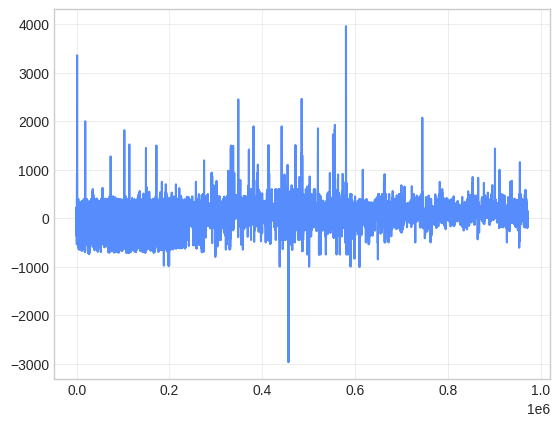

In [25]:
# Simple Plot of data
plt.plot(df['Imbalance Price'])

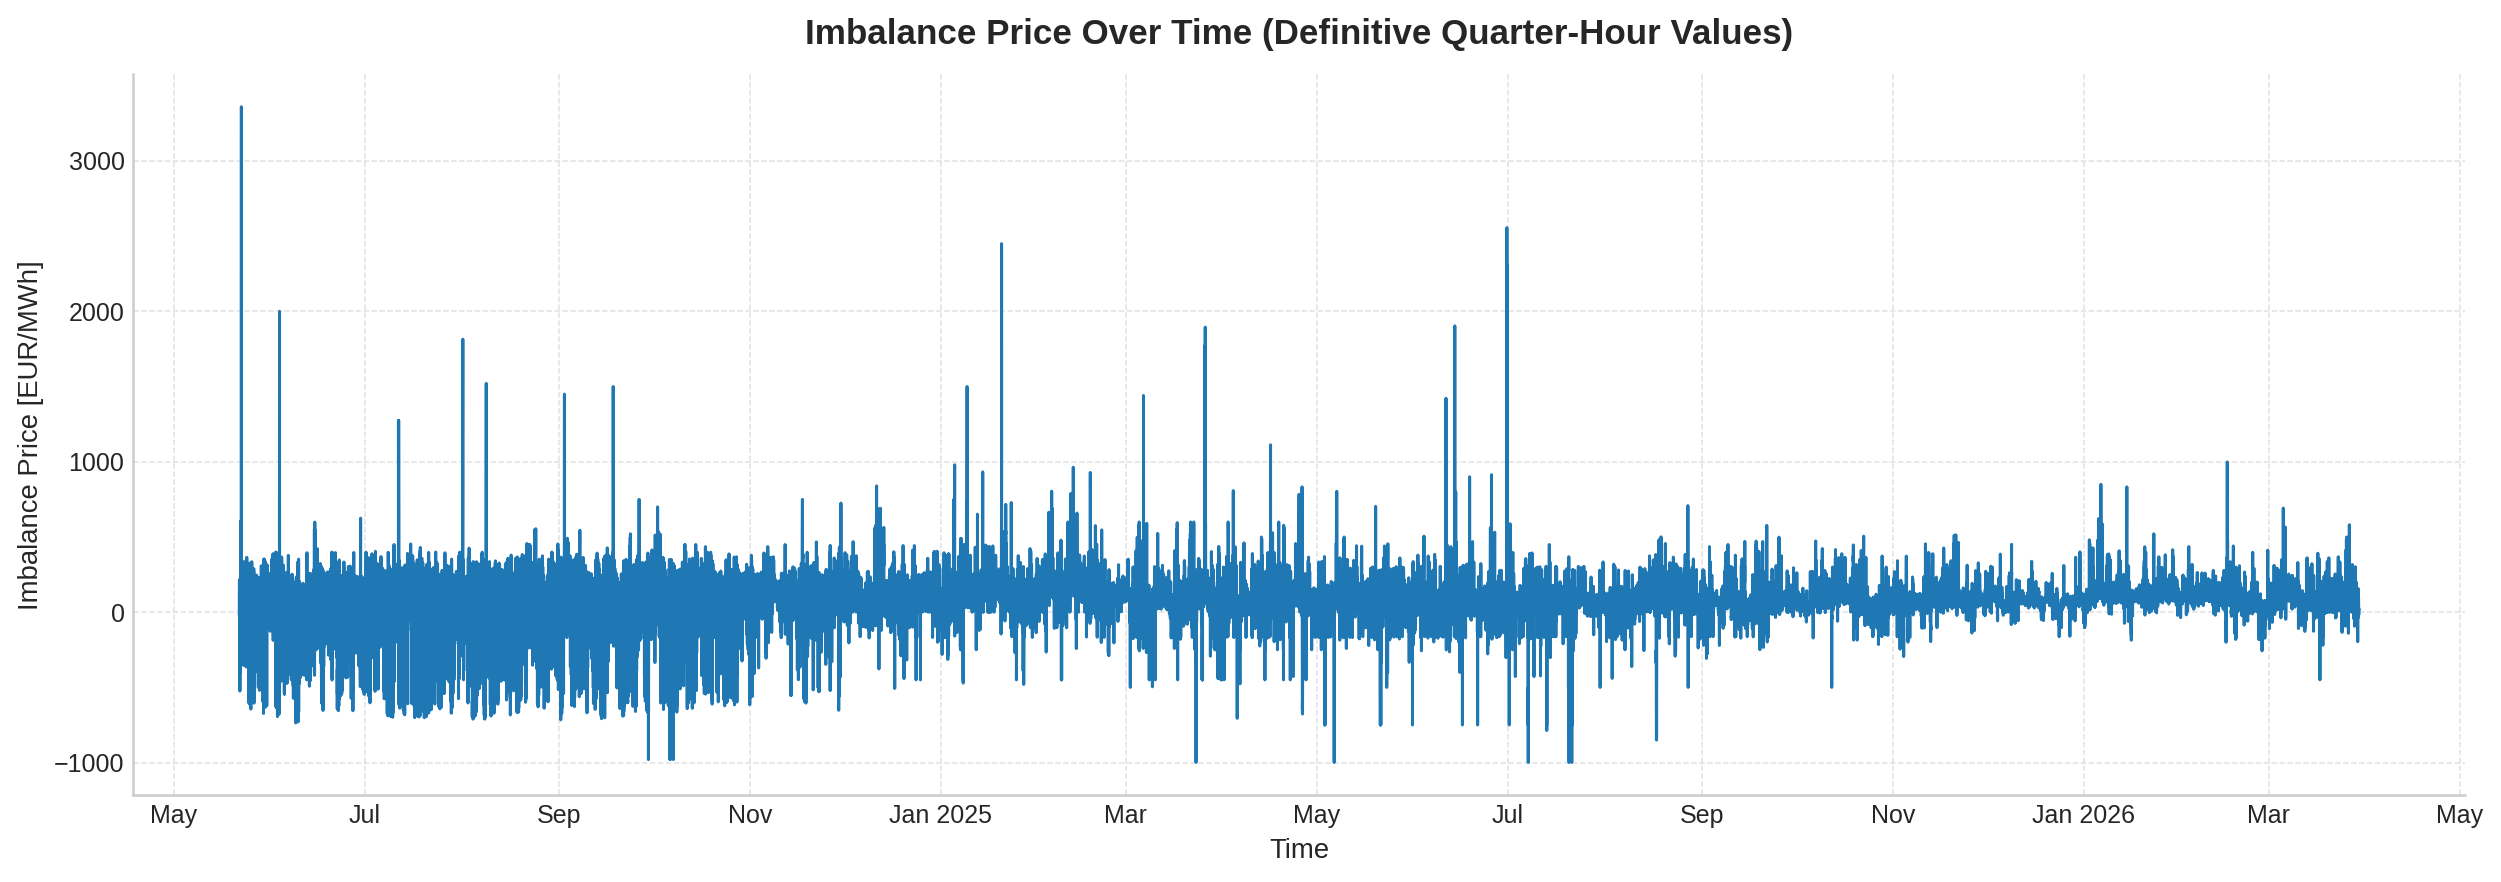

Saved: imbalance_price_thesis.png
Rows plotted: 64,784 / 971,601


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Load data
df = pd.read_pickle("raw_elia_data_cleaned.pkl")

# Ensure datetime axis is available and clean
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df = df.dropna(subset=["Datetime", "Imbalance Price"]).sort_values("Datetime")

# Keep only definitive prices at quarter-hour end minutes: 14, 29, 44, 59
definitive_minutes = [14, 29, 44, 59]
df_def = df[df["Datetime"].dt.minute.isin(definitive_minutes)].copy()

# Series to plot
s = df_def.set_index("Datetime")["Imbalance Price"].astype(float)

# Thesis-friendly style
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 5), dpi=180)

ax.plot(s.index, s.values, color="#1f77b4", linewidth=1.2)
ax.set_title("Imbalance Price Over Time (Definitive Quarter-Hour Values)", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Imbalance Price [EUR/MWh]", fontsize=11)

# Ticks: Jan, Mar, May, ... ; show year only on January
locator = mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11])
ax.xaxis.set_major_locator(locator)


def month_with_january_year(x, pos):
    dt = mdates.num2date(x)
    if dt.month == 1:
        return dt.strftime("%b %Y")  # e.g., Jan 2026
    return dt.strftime("%b")  # e.g., Mar, May, ...


ax.xaxis.set_major_formatter(FuncFormatter(month_with_january_year))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Visual polish
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.6)
ax.tick_params(axis="both", labelsize=10)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

# Save high-quality output for thesis
out_path = "plots/imbalance_price_thesis.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print(f"Rows plotted: {len(df_def):,} / {len(df):,}")


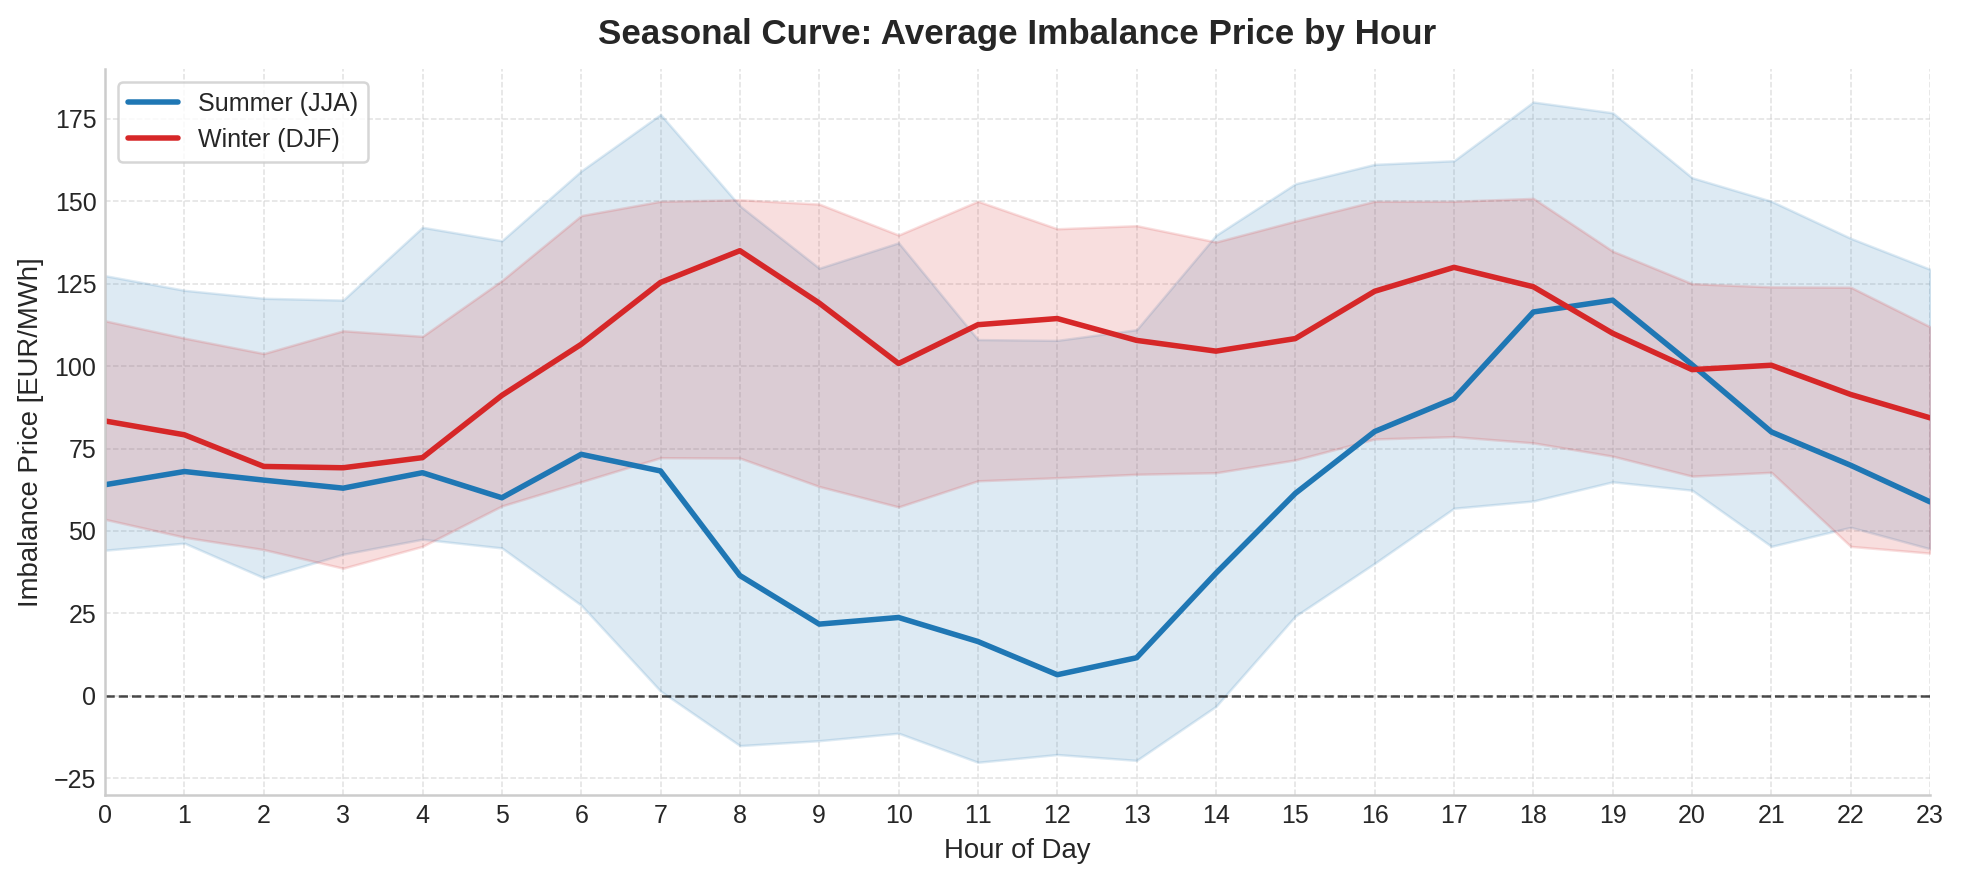

Saved: curve_summer_winter_prices.png
Summer points: 17,647 | Winter points: 17,238


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Add time features
df_def["hour"] = df_def["Datetime"].dt.hour
df_def["month"] = df_def["Datetime"].dt.month
df_def["price"] = df_def["Imbalance Price"].astype(float)

# Define seasons (meteorological)
summer_months = [6, 7, 8]  # Jun-Jul-Aug
winter_months = [12, 1, 2]  # Dec-Jan-Feb

summer = df_def[df_def["month"].isin(summer_months)].copy()
winter = df_def[df_def["month"].isin(winter_months)].copy()


# Hourly mean profile + optional spread (25-75 quantiles)
def hourly_profile(d):
    g = d.groupby("hour")["price"]
    out = pd.DataFrame({
        "mean": g.mean(),
        "q25": g.quantile(0.25),
        "q75": g.quantile(0.75)
    }).reindex(range(24))
    return out


summer_prof = hourly_profile(summer)
winter_prof = hourly_profile(winter)

# Plot
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 5), dpi=180)

# Mean lines
ax.plot(summer_prof.index, summer_prof["mean"], color="#1f77b4", lw=2.2, label="Summer (JJA)")
ax.plot(winter_prof.index, winter_prof["mean"], color="#d62728", lw=2.2, label="Winter (DJF)")

# Uncertainty bands (optional but thesis-friendly)
ax.fill_between(summer_prof.index, summer_prof["q25"], summer_prof["q75"], color="#1f77b4", alpha=0.15)
ax.fill_between(winter_prof.index, winter_prof["q25"], winter_prof["q75"], color="#d62728", alpha=0.15)

# Reference line at zero price
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.7)

# Labels and style
ax.set_title("Seasonal Curve: Average Imbalance Price by Hour", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Imbalance Price [EUR/MWh]", fontsize=11)
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
ax.legend(frameon=True, fontsize=10, loc="best")
ax.grid(True, ls="--", lw=0.6, alpha=0.6)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
out_path = "plots/curve_summer_winter_prices.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print(f"Summer points: {len(summer):,} | Winter points: {len(winter):,}")


/tmp/ipykernel_11917/1876737000.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


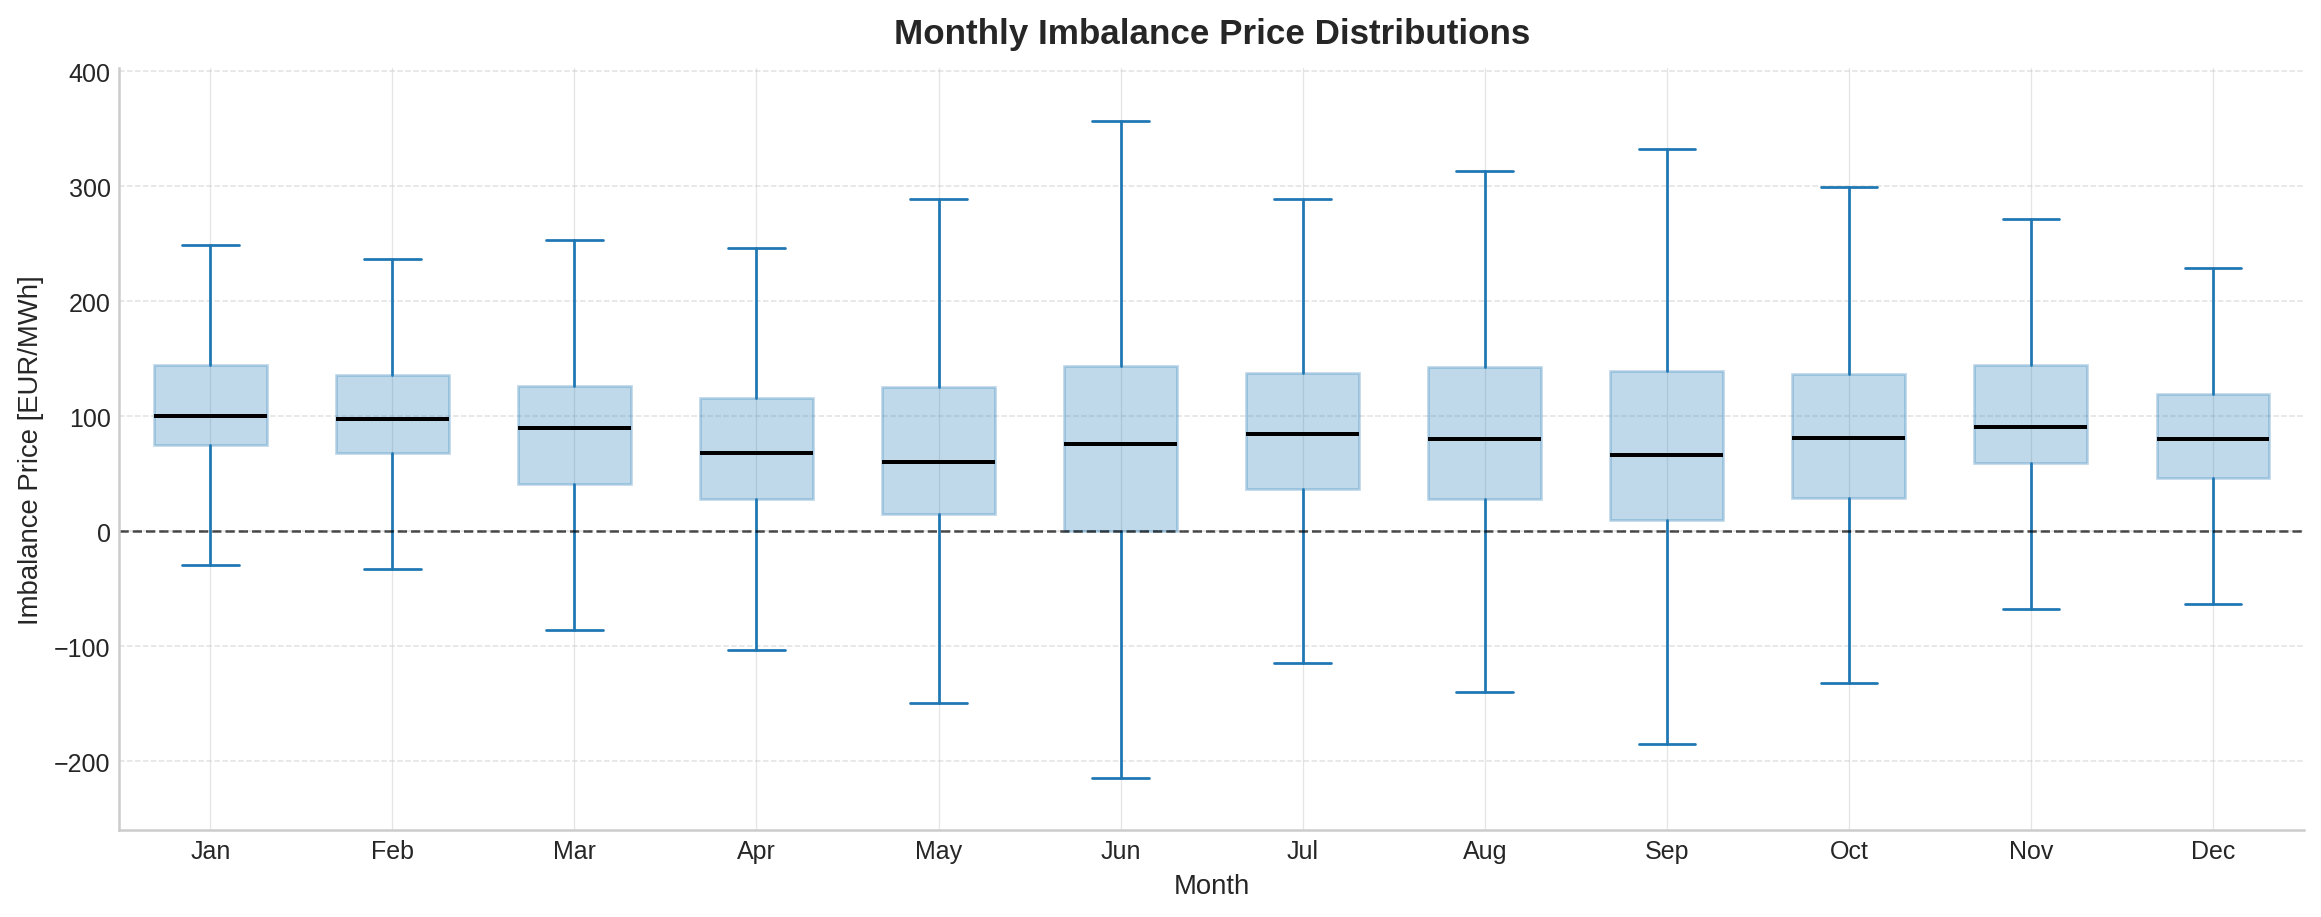

Saved: monthly_price_distributions_boxplot.png
Y-axis set to whisker-focused range: [-260.11, 402.72] EUR/MWh


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Reuse definitive-price dataframe from previous cells
d = df_def.copy()
d["month"] = d["Datetime"].dt.month
d["price"] = d["Imbalance Price"].astype(float)

# Build month-wise arrays in fixed Jan-Dec order
month_order = list(range(1, 13))
month_labels = [calendar.month_abbr[m] for m in month_order]
month_data = [d.loc[d["month"] == m, "price"].dropna().values for m in month_order]


# Helper: Tukey whisker bounds per month (same logic as whis=1.5)
def whisker_bounds(x):
    if len(x) == 0:
        return np.nan, np.nan
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    inliers = x[(x >= low_fence) & (x <= high_fence)]
    if len(inliers) == 0:
        return q1, q3
    return inliers.min(), inliers.max()


bounds = np.array([whisker_bounds(arr) for arr in month_data if len(arr) > 0], dtype=float)
y_min = np.nanmin(bounds[:, 0])
y_max = np.nanmax(bounds[:, 1])
pad = 0.08 * (y_max - y_min) if y_max > y_min else 1.0

# Thesis-friendly style
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 5.2), dpi=180)

box = ax.boxplot(
    month_data,
    labels=month_labels,
    patch_artist=True,
    showfliers=False,
    whis=1.5,
    widths=0.62,
    medianprops=dict(color="black", linewidth=1.6),
    boxprops=dict(linewidth=1.1, edgecolor="#1f77b4"),
    whiskerprops=dict(linewidth=1.1, color="#1f77b4"),
    capprops=dict(linewidth=1.1, color="#1f77b4"),
)

# One consistent color for all boxes
for patch in box["boxes"]:
    patch.set_facecolor("#1f77b4")
    patch.set_alpha(0.28)

# Labels and polish
ax.set_title("Monthly Imbalance Price Distributions", fontsize=14, weight="bold", pad=10)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Imbalance Price [EUR/MWh]", fontsize=11)
ax.grid(True, axis="y", ls="--", lw=0.6, alpha=0.6)

# Fit y-axis to whisker range (+small padding)
ax.set_ylim(y_min - pad, y_max + pad)

# Draw zero line only if visible in current y-range
if (y_min - pad) <= 0 <= (y_max + pad):
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.7)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

out_path = "plots/monthly_price_distributions_boxplot.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print(f"Y-axis set to whisker-focused range: [{y_min - pad:.2f}, {y_max + pad:.2f}] EUR/MWh")


/tmp/ipykernel_11917/774259976.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_11917/774259976.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


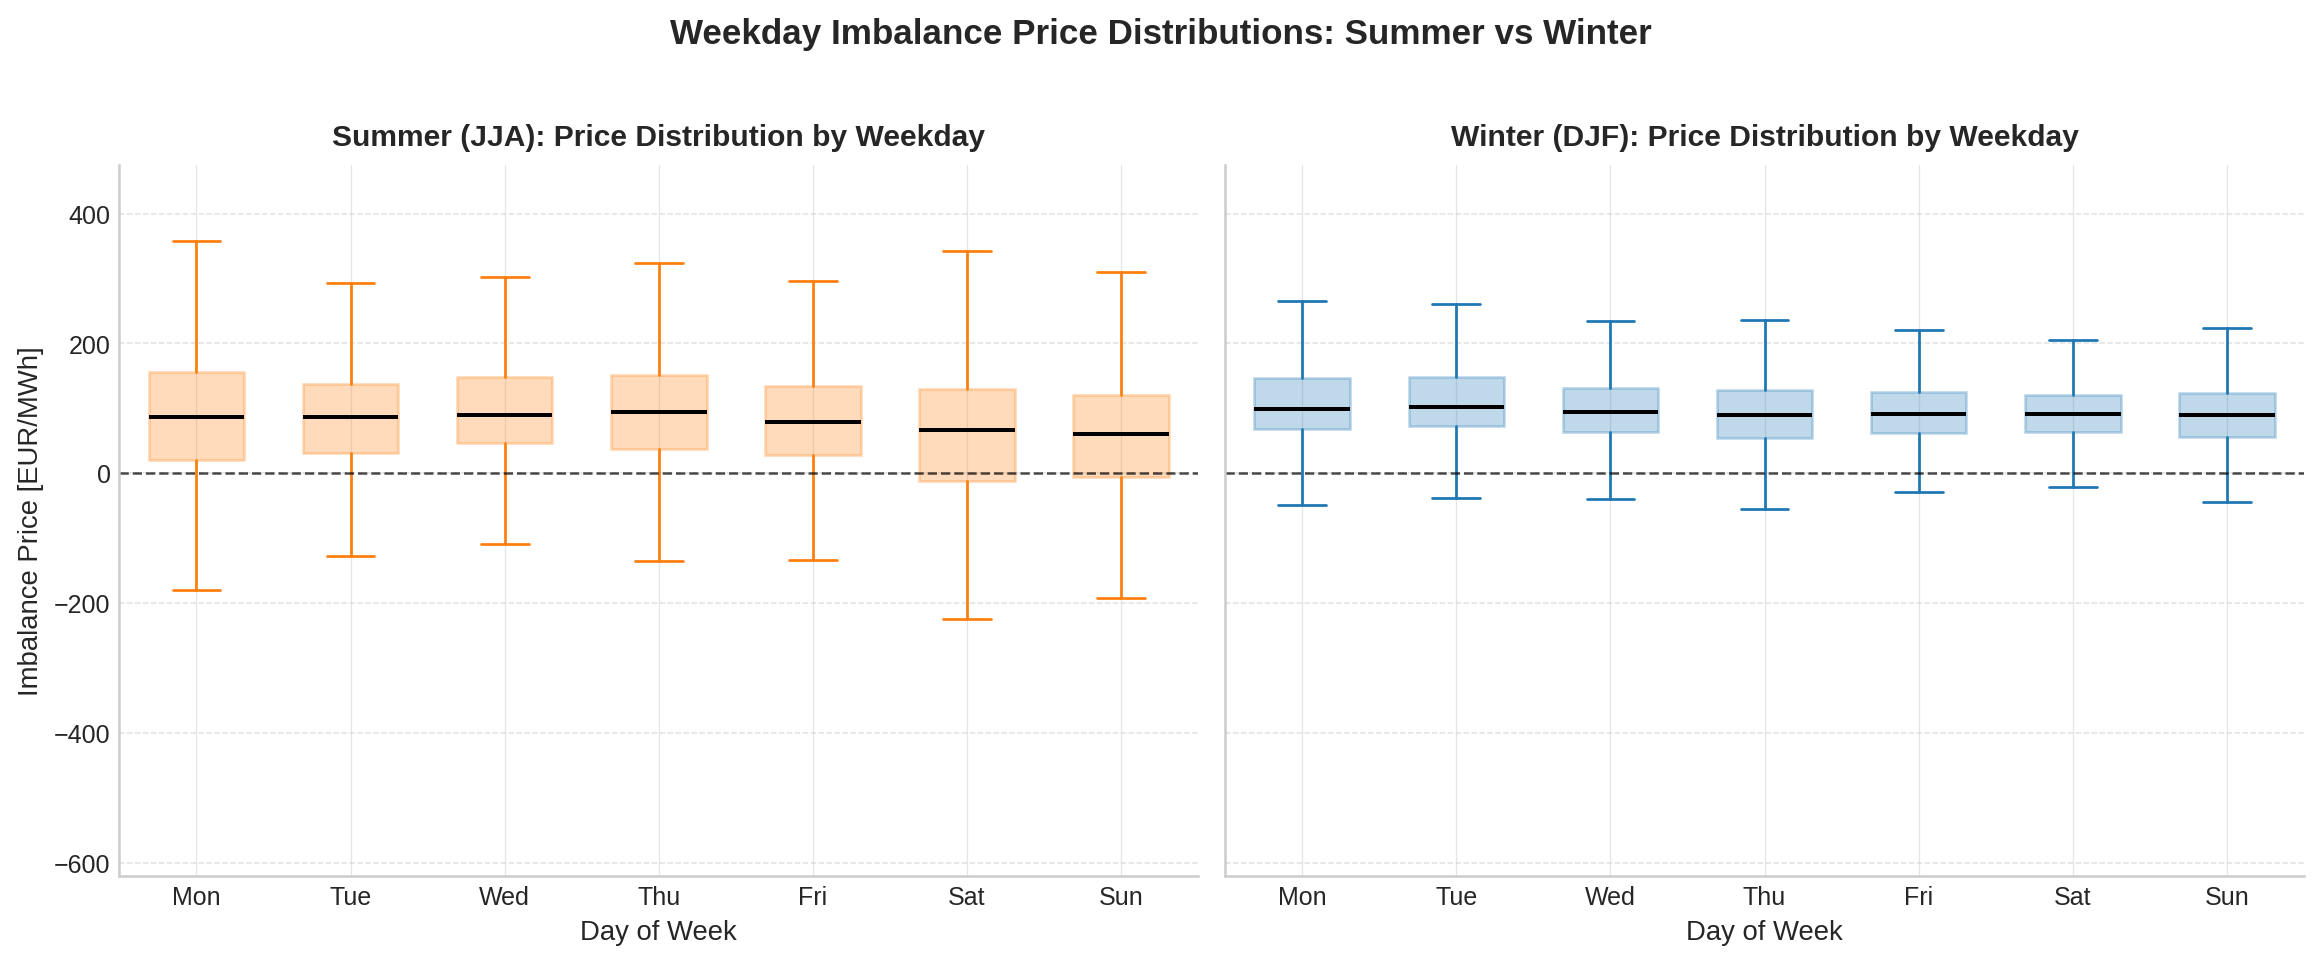

Saved: weekday_boxplots_summer_vs_winter.png
Summer points: 17,647 | Winter points: 17,238
Displayed y-range: [-621.14, 475.01] EUR/MWh


In [37]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reuse definitive quarter-hour data from earlier cells
d = df_def.copy()
d["Datetime"] = pd.to_datetime(d["Datetime"], errors="coerce")
d = d.dropna(subset=["Datetime", "Imbalance Price"]).copy()
d["price"] = d["Imbalance Price"].astype(float)

# Time features
d["weekday"] = d["Datetime"].dt.weekday  # Monday=0 ... Sunday=6
d["month"] = d["Datetime"].dt.month

# Seasons
summer = d[d["month"].isin([6, 7, 8])].copy()  # JJA
winter = d[d["month"].isin([12, 1, 2])].copy()  # DJF

weekday_order = list(range(7))
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

summer_data = [summer.loc[summer["weekday"] == wd, "price"].dropna().values for wd in weekday_order]
winter_data = [winter.loc[winter["weekday"] == wd, "price"].dropna().values for wd in weekday_order]

# Shared y-range based on robust quantiles across both seasons (readable + fair comparison)
combined = pd.concat([summer["price"], winter["price"]], axis=0).dropna()
y_low, y_high = combined.quantile([0.01, 0.99])
pad = 0.08 * (y_high - y_low)

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), dpi=180, sharey=True)


def draw_weekday_boxplot(ax, data, title, color):
    bp = ax.boxplot(
        data,
        labels=weekday_labels,
        patch_artist=True,
        showfliers=False,
        whis=1.5,
        widths=0.62,
        medianprops=dict(color="black", linewidth=1.6),
        boxprops=dict(linewidth=1.1, edgecolor=color),
        whiskerprops=dict(linewidth=1.1, color=color),
        capprops=dict(linewidth=1.1, color=color),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.28)

    ax.set_title(title, fontsize=12, weight="bold", pad=8)
    ax.set_xlabel("Day of Week", fontsize=11)
    ax.grid(True, axis="y", ls="--", lw=0.6, alpha=0.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


draw_weekday_boxplot(axes[0], summer_data, "Summer (JJA): Price Distribution by Weekday", "#ff7f0e")
draw_weekday_boxplot(axes[1], winter_data, "Winter (DJF): Price Distribution by Weekday", "#1f77b4")

axes[0].set_ylabel("Imbalance Price [EUR/MWh]", fontsize=11)

# Same y-axis for both panels
axes[0].set_ylim(y_low - pad, y_high + pad)
if (y_low - pad) <= 0 <= (y_high + pad):
    axes[0].axhline(0, color="black", lw=1, ls="--", alpha=0.7)
    axes[1].axhline(0, color="black", lw=1, ls="--", alpha=0.7)

fig.suptitle("Weekday Imbalance Price Distributions: Summer vs Winter", fontsize=14, weight="bold", y=1.02)
fig.tight_layout()

out_path = "plots/weekday_boxplots_summer_vs_winter.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")
print(f"Summer points: {len(summer):,} | Winter points: {len(winter):,}")
print(f"Displayed y-range: [{y_low - pad:.2f}, {y_high + pad:.2f}] EUR/MWh")
